# Cross-Sectional De-Time Factor Selection

This notebook turns De-Time features into cross-sectional alpha candidates. The score combines trend strength, cheap residual pullback, cycle slope, and a penalty for noisy decompositions.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
for path in [ROOT / "src", ROOT / "examples"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

In [2]:
universe = DEFAULT_UNIVERSES["us_large_cap"][:10]
prices = fetch_yahoo_prices(universe, start="2017-01-01", cache_dir=ROOT / "examples" / "quant_trading" / "data" / "cache")
features = walkforward_decompose(prices, method="STL", period=63, train_window=252, step=21)
weights = cross_sectional_rotation_weights(prices, features, top_n=3, vol_target=0.15)
result = backtest_weights(prices, weights, fee_bps=1.0, slippage_bps=3.0)
result.stats_frame()

,value
total_return,4.315378
cagr,0.195287
volatility,0.157839
sharpe,1.209254
max_drawdown,-0.287963
calmar,0.678168
hit_rate,0.491525
average_turnover,0.040488
average_gross_exposure,0.528434
fee_bps,1.000000


In [3]:
weights.tail(10)

Ticker,AAPL,MSFT,NVDA,AMZN,META,GOOGL,TSLA,JPM,XOM,UNH
Date,,,,,,,,,,
2026-05-11,0.0,0.0,0.000000,0.0,0.219794,0.219794,0.0,0.0,0.219794,0.000000
2026-05-12,0.0,0.0,0.220982,0.0,0.000000,0.000000,0.0,0.0,0.220982,0.220982
2026-05-13,0.0,0.0,0.219663,0.0,0.000000,0.000000,0.0,0.0,0.219663,0.219663
2026-05-14,0.0,0.0,0.218319,0.0,0.000000,0.000000,0.0,0.0,0.218319,0.218319
2026-05-15,0.0,0.0,0.217989,0.0,0.000000,0.000000,0.0,0.0,0.217989,0.217989
2026-05-18,0.0,0.0,0.221092,0.0,0.000000,0.000000,0.0,0.0,0.221092,0.221092
2026-05-19,0.0,0.0,0.223324,0.0,0.000000,0.000000,0.0,0.0,0.223324,0.223324
2026-05-20,0.0,0.0,0.221390,0.0,0.000000,0.000000,0.0,0.0,0.221390,0.221390
2026-05-21,0.0,0.0,0.222153,0.0,0.000000,0.000000,0.0,0.0,0.222153,0.222153


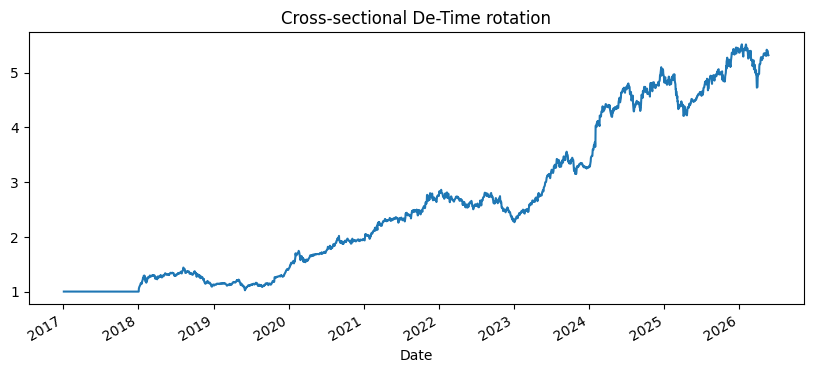

In [4]:
result.equity.plot(figsize=(10, 4), title="Cross-sectional De-Time rotation")
plt.show()